# Notebook 1A — Phase I Imbalance

*Restructured for traceability — code, results, and outputs unchanged. Each code cell is preceded by a numbered markdown heading. Cell numbering matches the report's Notebook + Cell references.*

## Cell 1 — Imports


In [ ]:
# Cell 1 — Imports

import os, random, time, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from PIL import Image

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score


## Cell 2 — Configuration (CFG, classes, device)


In [ ]:

# Cell 2 — Config (KEEP NAMES STABLE)
class CFG:
    seed = 42
    img_size = 224
    batch_size = 32

    # Keep epochs equal for fair A/B/C/D comparison
    epochs = 14

    lr = 3e-4
    weight_decay = 1e-4

    # DataLoader workers:
    num_workers_drive = 0   # Drive is slow/unstable with workers>0
    num_workers_local = 2   # cache to /content -> can use 2-4

    cache_to_local = True

    # Paths (auto-detected)
    DRIVE_ROOT = None
    DATA_ROOT  = None
    CSV_PATH   = None
    IMG_DIR1   = None
    IMG_DIR2   = None

    CACHE_DIR = Path("/content/ham_cache/images")
    RUN_DIR = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Cell 3 — Reproducibility — seed_everything(42)


In [ ]:
# Cell 3 — Reproducibility

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(CFG.seed)


## Cell 4 — Drive mount (Colab-safe)


In [ ]:
# Cell 4 — Safe Drive Mount (Colab-safe)

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive", force_remount=False)
    print("✅ Drive ready:", os.path.exists("/content/drive/MyDrive"))
else:
    print("ℹ️ Not in Colab (Drive mount skipped)")


Mounted at /content/drive
✅ Drive ready: True


## Cell 5 — Path resolution + RUN_DIR


In [ ]:
# Cell 5 — Auto-detect dataset paths + set RUN_DIR

def resolve_ham10000_paths():
    search_roots = []
    if IN_COLAB and os.path.exists("/content/drive/MyDrive"):
        search_roots.append(Path("/content/drive/MyDrive"))
    search_roots.append(Path.cwd())

    csv_path = None
    for root in search_roots:
        cands = list(root.rglob("HAM10000_metadata.csv"))
        if len(cands) > 0:
            csv_path = cands[0]
            break
    if csv_path is None:
        raise FileNotFoundError("Could not find HAM10000_metadata.csv. Put HAM10000 folder in Drive or current folder.")

    data_root = csv_path.parent

    img1 = None
    img2 = None
    for root in [data_root] + search_roots:
        c1 = list(root.rglob("HAM10000_images_part_1"))
        c2 = list(root.rglob("HAM10000_images_part_2"))
        if len(c1) > 0 and len(c2) > 0:
            img1, img2 = c1[0], c2[0]
            break
    if img1 is None or img2 is None:
        raise FileNotFoundError("Could not find HAM10000_images_part_1 and HAM10000_images_part_2.")

    drive_root = Path("/content/drive/MyDrive") if (IN_COLAB and os.path.exists("/content/drive/MyDrive")) else Path.cwd()
    return drive_root, data_root, csv_path, img1, img2

CFG.DRIVE_ROOT, CFG.DATA_ROOT, CFG.CSV_PATH, CFG.IMG_DIR1, CFG.IMG_DIR2 = resolve_ham10000_paths()

CFG.RUN_DIR = CFG.DRIVE_ROOT / "ham_runs" / "notebook1_cnn_final_plus"
CFG.RUN_DIR.mkdir(parents=True, exist_ok=True)

print("CSV_PATH:", CFG.CSV_PATH)
print("IMG_DIR1:", CFG.IMG_DIR1)
print("IMG_DIR2:", CFG.IMG_DIR2)
print("RUN_DIR :", CFG.RUN_DIR)


CSV_PATH: /content/drive/MyDrive/HAM10000/HAM10000_metadata.csv
IMG_DIR1: /content/drive/MyDrive/HAM10000/HAM10000_images_part_1
IMG_DIR2: /content/drive/MyDrive/HAM10000/HAM10000_images_part_2
RUN_DIR : /content/drive/MyDrive/ham_runs/notebook1_cnn_final_plus


## Cell 6 — Metadata loading + label map


In [ ]:

# Cell 6 — Load metadata + labels

df = pd.read_csv(CFG.CSV_PATH)

label_col = "dx"
imgid_col = "image_id"
group_col = "lesion_id"

classes = sorted(df[label_col].unique())
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
df["y"] = df[label_col].map(class_to_idx).astype(int)

print("Classes:", classes)
df[[imgid_col, group_col, label_col, "y"]].head()


Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


,image_id,lesion_id,dx,y
0,ISIC_0027419,HAM_0000118,bkl,2
1,ISIC_0025030,HAM_0000118,bkl,2
2,ISIC_0026769,HAM_0002730,bkl,2
3,ISIC_0025661,HAM_0002730,bkl,2
4,ISIC_0031633,HAM_0001466,bkl,2


## Cell 7 — Image-path index


In [ ]:

# Cell 7 — Resolve image paths
def build_img_index(img_dir1: Path, img_dir2: Path):
    idx = {}
    for d in (img_dir1, img_dir2):
        for p in d.glob("*.jpg"):
            idx[p.stem] = p
    return idx

img_index = build_img_index(CFG.IMG_DIR1, CFG.IMG_DIR2)
print("Indexed images:", len(img_index))

paths = []
missing = 0
for img_id in df[imgid_col].values:
    p = img_index.get(img_id, None)
    if p is None:
        paths.append("")
        missing += 1
    else:
        paths.append(str(p))
df["path"] = paths

print("Missing paths:", missing)
df = df[df["path"] != ""].reset_index(drop=True)
print("After drop:", len(df))


Indexed images: 10044
Missing paths: 0
After drop: 10015


## Cell 8 — Lesion-wise group split (no leakage)


In [ ]:

# Cell 8 — Group split by lesion_id (no leakage)
def group_split(df_in, group_col="lesion_id", test_size=0.15, val_size=0.15, seed=42):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trval_idx, te_idx = next(gss1.split(df_in, groups=df_in[group_col]))
    trval = df_in.iloc[trval_idx].reset_index(drop=True)
    test  = df_in.iloc[te_idx].reset_index(drop=True)

    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
    tr_idx, va_idx = next(gss2.split(trval, groups=trval[group_col]))
    train = trval.iloc[tr_idx].reset_index(drop=True)
    val   = trval.iloc[va_idx].reset_index(drop=True)
    return train, val, test

train_df, val_df, test_df = group_split(df, group_col=group_col, test_size=0.15, val_size=0.15, seed=CFG.seed)

print("Sizes:", len(train_df), len(val_df), len(test_df))
print("Train distribution:\n", train_df["y"].value_counts().sort_index())

assert set(train_df[group_col]).isdisjoint(set(val_df[group_col]))
assert set(train_df[group_col]).isdisjoint(set(test_df[group_col]))
assert set(val_df[group_col]).isdisjoint(set(test_df[group_col]))
print("✅ No lesion_id leakage across splits")


Sizes: 7182 1306 1527
Train distribution:
 y
0     226
1     367
2     792
3      92
4     798
5    4809
6      98
Name: count, dtype: int64
✅ No lesion_id leakage across splits


## Cell 9 — Image cache (ZIP → /content)


In [ ]:

# Cell 9 — FAST Cache using ZIP


CFG.CACHE_DIR.mkdir(parents=True, exist_ok=True)

def make_drive_zip_if_missing(img_index, zip_path: Path):
    if zip_path.exists():
        print("✅ Zip already exists:", zip_path)
        return
    print("📦 Creating zip in Drive (one-time)...")
    t0 = time.time()
    items = list(img_index.items())
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_STORED) as zf:
        for i, (_, src) in enumerate(items, start=1):
            src = Path(src)
            if src.exists():
                zf.write(src, arcname=src.name)
            if i % 2000 == 0:
                print(f"  ... zipped {i}/{len(items)}")
    print(f"✅ Zip created: {zip_path} | time={(time.time()-t0)/60:.1f} min")

def unzip_to_cache(zip_local: Path, out_dir: Path):
    print("📦 Unzipping to cache...")
    t0 = time.time()
    with zipfile.ZipFile(zip_local, "r") as zf:
        zf.extractall(out_dir)
    print(f"✅ Unzip done | time={(time.time()-t0)/60:.1f} min")

if IN_COLAB and CFG.cache_to_local:
    drive_zip = CFG.DRIVE_ROOT / "HAM10000_cache_images.zip"
    local_zip = Path("/content/HAM10000_cache_images.zip")

    cached_count = len(list(CFG.CACHE_DIR.glob("*.jpg")))
    if cached_count > 9000:
        print(f"✅ Cache already ready: {cached_count} jpg. Skipping caching.")
    else:
        make_drive_zip_if_missing(img_index, drive_zip)
        if not local_zip.exists():
            print("🚀 Copying zip to /content...")
            shutil.copyfile(drive_zip, local_zip)

        # clear old cache
        for p in CFG.CACHE_DIR.glob("*.jpg"):
            p.unlink()

        unzip_to_cache(local_zip, CFG.CACHE_DIR)

    def to_cache_path(p):
        return str(CFG.CACHE_DIR / Path(p).name)

    for _df in (train_df, val_df, test_df):
        _df["path"] = _df["path"].map(to_cache_path)

    assert Path(train_df["path"].iloc[0]).exists(), "Cache mapping failed."
    print("✅ Using cached paths:", CFG.CACHE_DIR)
else:
    print("ℹ️ Cache disabled — using original paths.")


✅ Zip already exists: /content/drive/MyDrive/HAM10000_cache_images.zip
🚀 Copying zip to /content...
📦 Unzipping to cache...
✅ Unzip done | time=0.3 min
✅ Using cached paths: /content/ham_cache/images


## Cell 10 — Transforms (light vs strong)


In [ ]:
# Cell 10 — Transforms (has resizing )

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

tfm_base = T.Compose([
    T.Resize((CFG.img_size, CFG.img_size)),  #  resizing
    T.ToTensor(),
    T.Normalize(mean, std),
])

tfm_train = T.Compose([
    T.Resize((CFG.img_size, CFG.img_size)),  #  resizing
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.05, hue=0.01),
    T.ToTensor(),
    T.Normalize(mean, std),
])

print(" Transforms ready (with resizing)")


✅ Transforms ready (with resizing)


## Cell 11 — Robust HamDataset


In [ ]:

# Cell 11 — Robust Dataset

class HamDataset(Dataset):
    def __init__(self, df, tfm, img_index=None, cache_dir=None):
        self.df = df.reset_index(drop=True)
        self.tfm = tfm
        self.img_index = img_index
        self.cache_dir = Path(cache_dir) if cache_dir else None

    def __len__(self):
        return len(self.df)

    def _repair_if_cached(self, path_str):
        if self.img_index is None or self.cache_dir is None:
            return False
        p = Path(path_str)
        if str(p).startswith(str(self.cache_dir)):
            src = self.img_index.get(p.stem, None)
            if src is None:
                return False
            try:
                p.unlink(missing_ok=True)
                shutil.copyfile(src, p)
                return True
            except Exception:
                return False
        return False

    def __getitem__(self, i):
        row = self.df.iloc[i]
        path = row["path"]
        y = int(row["y"])
        try:
            img = Image.open(path); img.load(); img = img.convert("RGB")
        except Exception:
            if self._repair_if_cached(path):
                img = Image.open(path); img.load(); img = img.convert("RGB")
            else:
                j = random.randint(0, len(self.df)-1)
                return self.__getitem__(j)
        return self.tfm(img), y


## Cell 12 — DataLoaders + WeightedRandomSampler


In [ ]:

# Cell 12 — DataLoaders + Sampler

using_drive = (IN_COLAB and str(train_df["path"].iloc[0]).startswith("/content/drive"))
num_workers = CFG.num_workers_drive if using_drive else CFG.num_workers_local
print("using_drive:", using_drive, "| num_workers:", num_workers)

train_ds = HamDataset(train_df, tfm_train, img_index=img_index, cache_dir=CFG.CACHE_DIR)
val_ds   = HamDataset(val_df,   tfm_base,  img_index=img_index, cache_dir=CFG.CACHE_DIR)
test_ds  = HamDataset(test_df,  tfm_base,  img_index=img_index, cache_dir=CFG.CACHE_DIR)

train_loader_A = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                            num_workers=num_workers, pin_memory=True)

class_counts = train_df["y"].value_counts().sort_index().values
inv_freq = 1.0 / class_counts
sample_weights = train_df["y"].map(lambda y: inv_freq[y]).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=int(0.7 * len(sample_weights)),
    replacement=True
)

train_loader_B = DataLoader(train_ds, batch_size=CFG.batch_size, sampler=sampler,
                            num_workers=num_workers, pin_memory=True)

train_loader_C = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                            num_workers=num_workers, pin_memory=True)

train_loader_D = DataLoader(train_ds, batch_size=CFG.batch_size, sampler=sampler,
                            num_workers=num_workers, pin_memory=True)

val_loader  = DataLoader(val_ds,  batch_size=CFG.batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

print("Class counts (train):", dict(zip([c for c in classes], class_counts)))


using_drive: False | num_workers: 2
Class counts (train): {'akiec': np.int64(226), 'bcc': np.int64(367), 'bkl': np.int64(792), 'df': np.int64(92), 'mel': np.int64(798), 'nv': np.int64(4809), 'vasc': np.int64(98)}


## Cell 13 — Sampler-balance audit (figure)


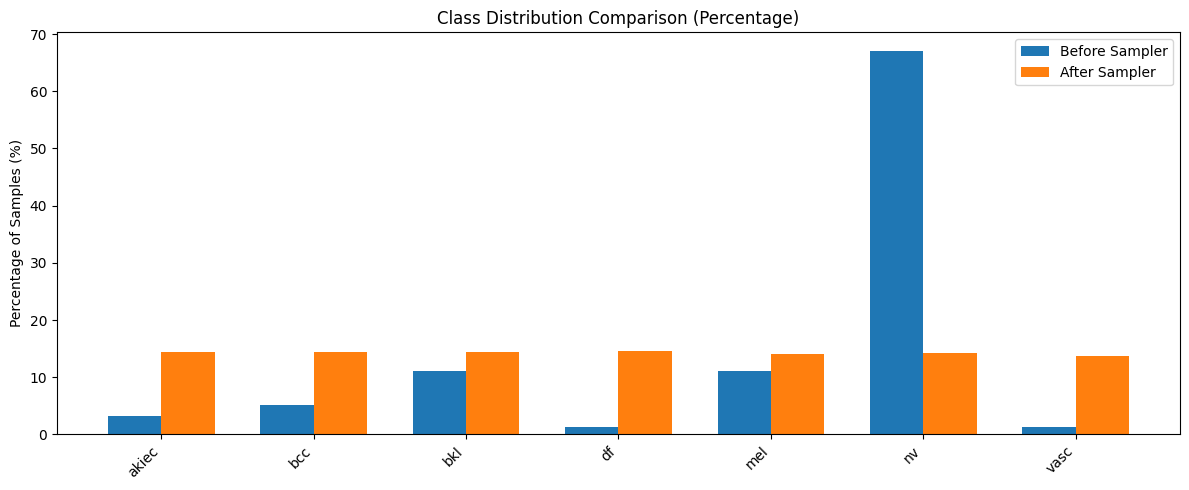


Percentage Distribution BEFORE Sampler:
akiec : 3.15%
bcc   : 5.11%
bkl   : 11.03%
df    : 1.28%
mel   : 11.11%
nv    : 66.96%
vasc  : 1.36%

Percentage Distribution AFTER Sampler (Simulated):
akiec : 14.34%
bcc   : 14.48%
bkl   : 14.46%
df    : 14.64%
mel   : 14.08%
nv    : 14.22%
vasc  : 13.77%


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

labels = [idx_to_class[i] for i in range(len(classes))]

# -------- BEFORE (real train distribution) --------
counts_real = train_df["y"].value_counts().sort_index()
values_real = np.array([counts_real.get(i, 0) for i in range(len(classes))])
perc_real = values_real / values_real.sum() * 100

# -------- AFTER (simulate sampler) --------
N = 20000  # larger = smoother estimate

ys = train_df["y"].values
sampled_counts = Counter()

for i, idx in enumerate(iter(sampler)):
    sampled_counts[int(ys[idx])] += 1
    if i >= N - 1:
        break

values_sampled = np.array([sampled_counts.get(i, 0) for i in range(len(classes))])
perc_sampled = values_sampled / values_sampled.sum() * 100

# -------- Plot --------
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12,5))
plt.bar(x - width/2, perc_real, width, label="Before Sampler")
plt.bar(x + width/2, perc_sampled, width, label="After Sampler")

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Percentage of Samples (%)")
plt.title("Class Distribution Comparison (Percentage)")
plt.legend()
plt.tight_layout()
plt.show()

# Print percentages cleanly
print("\nPercentage Distribution BEFORE Sampler:")
for l, p in zip(labels, perc_real):
    print(f"{l:6s}: {p:.2f}%")

print("\nPercentage Distribution AFTER Sampler (Simulated):")
for l, p in zip(labels, perc_sampled):
    print(f"{l:6s}: {p:.2f}%")


# Cell 14 — CNN Architecture

In [ ]:

# Cell 14 — CNN Architecture

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, p=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(p)
        )
    def forward(self, x):
        return self.block(x)

class StrongCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32, p=0.10),
            ConvBlock(32,  64, p=0.15),
            ConvBlock(64, 128, p=0.20),
            ConvBlock(128,256, p=0.25),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)

print("✅ Model ready")


✅ Model ready


##  Cell 15 — Optim / Loss / AMP




In [ ]:
# Cell 15 — Optim / Loss / AMP

from torch.amp import autocast, GradScaler

def make_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

def make_scaler():
    return GradScaler("cuda") if device.type == "cuda" else GradScaler("cpu")

def make_loss_label_smoothing():
    return nn.CrossEntropyLoss(label_smoothing=0.05)

def make_loss_weighted_ce(class_counts_np):
    counts = class_counts_np.astype(np.float32)
    w = (counts.sum() / (counts + 1e-6))
    w = w / w.mean()
    w = torch.tensor(w, dtype=torch.float32, device=device)
    return nn.CrossEntropyLoss(weight=w), w

print("✅ Optim/Loss helpers ready")


✅ Optim/Loss helpers ready


## Cell 16 Train/eval loops


In [ ]:

# Cell 16 — Train/Eval loops

def evaluate(model, loader, criterion):
    model.eval()
    ys, ps = [], []
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            pred = logits.argmax(1)
            ys.extend(y.cpu().numpy())
            ps.extend(pred.cpu().numpy())

    ys = np.array(ys); ps = np.array(ps)
    acc = (ys == ps).mean()
    bacc = balanced_accuracy_score(ys, ps)
    f1 = f1_score(ys, ps, average="weighted")
    cm = confusion_matrix(ys, ps)
    return total_loss/len(loader.dataset), acc, bacc, f1, cm, ys, ps

def train_one_epoch(model, loader, optimizer, scaler, criterion, clip_grad=1.0):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, enabled=(device.type=="cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * x.size(0)

    return total_loss/len(loader.dataset)

print("✅ Train/Eval ready")


✅ Train/Eval ready


##  Cell 17 — Plot helpers


In [ ]:

# Cell 17 — Plot helpers

def plot_history(hist_df, title):
    plt.figure(figsize=(10,4))
    plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
    plt.title(title + " — Loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
    plt.plot(hist_df["epoch"], hist_df["val_bacc"], label="val_bacc")
    plt.plot(hist_df["epoch"], hist_df["val_f1"], label="val_f1")
    plt.title(title + " — Metrics")
    plt.xlabel("epoch"); plt.ylabel("metric"); plt.legend()
    plt.show()

def plot_cm(cm, title, labels):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="viridis")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.colorbar()
    plt.show()


##  Cell 18 — Run experiment (cosine LR + early stopping)


In [ ]:

# Cell 18 — Run experiment (cosine LR + early stopping)

def run_experiment(tag, train_loader, val_loader, criterion, epochs, patience=3):
    seed_everything(CFG.seed)
    model = StrongCNN(len(classes)).to(device)
    opt = make_optimizer(model)
    scaler = make_scaler()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    best_bacc = -1
    best_path = str(CFG.RUN_DIR / f"best_{tag}.pt")
    hist = []
    bad = 0

    for ep in range(1, epochs+1):
        tr_loss = train_one_epoch(model, train_loader, opt, scaler, criterion)
        va_loss, va_acc, va_bacc, va_f1, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        hist.append([ep, tr_loss, va_loss, va_acc, va_bacc, va_f1])

        if va_bacc > best_bacc + 1e-4:
            best_bacc = va_bacc
            torch.save(model.state_dict(), best_path)
            bad = 0
        else:
            bad += 1

        print(f"[{tag}] ep {ep:02d} | tr_loss {tr_loss:.4f} | val_loss {va_loss:.4f} | "
              f"val_acc {va_acc:.4f} | val_bacc {va_bacc:.4f} | val_f1 {va_f1:.4f} | bad={bad}")

        if bad >= patience:
            print(f"🛑 Early stopping: no val_bacc improvement for {patience} epochs.")
            break

    hist = pd.DataFrame(hist, columns=["epoch","train_loss","val_loss","val_acc","val_bacc","val_f1"])
    print("✅ Best val_bacc:", best_bacc, "| saved:", best_path)
    return hist, best_path


##  Cell 19 — A: Baseline


In [ ]:

# Cell 19 — A: Baseline

critA = make_loss_label_smoothing()
histA, bestA_path = run_experiment("A_baseline", train_loader_A, val_loader, critA, CFG.epochs)


[A_baseline] ep 01 | tr_loss 1.0732 | val_loss 1.0479 | val_acc 0.6730 | val_bacc 0.1624 | val_f1 0.5678 | bad=0
[A_baseline] ep 02 | tr_loss 1.0081 | val_loss 1.0007 | val_acc 0.6868 | val_bacc 0.1959 | val_f1 0.6085 | bad=0
[A_baseline] ep 03 | tr_loss 0.9752 | val_loss 1.0380 | val_acc 0.6485 | val_bacc 0.2660 | val_f1 0.6328 | bad=0
[A_baseline] ep 04 | tr_loss 0.9424 | val_loss 0.9501 | val_acc 0.7014 | val_bacc 0.2481 | val_f1 0.6591 | bad=1
[A_baseline] ep 05 | tr_loss 0.9336 | val_loss 0.9440 | val_acc 0.7144 | val_bacc 0.2538 | val_f1 0.6609 | bad=2
[A_baseline] ep 06 | tr_loss 0.9175 | val_loss 0.9326 | val_acc 0.7259 | val_bacc 0.3006 | val_f1 0.6924 | bad=0
[A_baseline] ep 07 | tr_loss 0.9112 | val_loss 0.9073 | val_acc 0.7243 | val_bacc 0.2899 | val_f1 0.6868 | bad=1
[A_baseline] ep 08 | tr_loss 0.8972 | val_loss 0.9151 | val_acc 0.7312 | val_bacc 0.3443 | val_f1 0.7161 | bad=0
[A_baseline] ep 09 | tr_loss 0.8832 | val_loss 0.8900 | val_acc 0.7328 | val_bacc 0.3107 | val_f

## Cell 20 — B: Sampler onlyCell 20 — B: Sampler only


In [ ]:
# Cell 20 — B: Sampler only

critB = make_loss_label_smoothing()
histB, bestB_path = run_experiment("B_sampler_only", train_loader_B, val_loader, critB, CFG.epochs)


[B_sampler_only] ep 01 | tr_loss 1.1400 | val_loss 1.4905 | val_acc 0.4495 | val_bacc 0.4434 | val_f1 0.5077 | bad=0
[B_sampler_only] ep 02 | tr_loss 1.0303 | val_loss 1.7534 | val_acc 0.3698 | val_bacc 0.4435 | val_f1 0.4163 | bad=0
[B_sampler_only] ep 03 | tr_loss 0.9919 | val_loss 1.3003 | val_acc 0.5329 | val_bacc 0.5312 | val_f1 0.5836 | bad=0
[B_sampler_only] ep 04 | tr_loss 0.9641 | val_loss 1.3014 | val_acc 0.5199 | val_bacc 0.5250 | val_f1 0.5761 | bad=1
[B_sampler_only] ep 05 | tr_loss 0.9187 | val_loss 1.3607 | val_acc 0.5031 | val_bacc 0.5065 | val_f1 0.5504 | bad=2
[B_sampler_only] ep 06 | tr_loss 0.8891 | val_loss 1.1176 | val_acc 0.6057 | val_bacc 0.5172 | val_f1 0.6444 | bad=3
🛑 Early stopping: no val_bacc improvement for 3 epochs.
✅ Best val_bacc: 0.5312342140007783 | saved: /content/drive/MyDrive/ham_runs/notebook1_cnn_final_plus/best_B_sampler_only.pt


## Cell 21 — C: Weighted loss only


In [ ]:

# Cell 21 — C: Weighted loss only

critC, loss_weights = make_loss_weighted_ce(class_counts)
print("Loss weights (C/D):", loss_weights.detach().cpu().numpy())
histC, bestC_path = run_experiment("C_weighted_loss_only", train_loader_C, val_loader, critC, CFG.epochs)


Loss weights (C/D): [1.0008572  0.6163317  0.28559816 2.4586275  0.28345078 0.0470355
 2.3080993 ]
[C_weighted_loss_only] ep 01 | tr_loss 1.7217 | val_loss 1.3327 | val_acc 0.4717 | val_bacc 0.3881 | val_f1 0.5216 | bad=0
[C_weighted_loss_only] ep 02 | tr_loss 1.5628 | val_loss 1.4204 | val_acc 0.4533 | val_bacc 0.4267 | val_f1 0.5140 | bad=0
[C_weighted_loss_only] ep 03 | tr_loss 1.5074 | val_loss 1.2523 | val_acc 0.4625 | val_bacc 0.4159 | val_f1 0.5212 | bad=1
[C_weighted_loss_only] ep 04 | tr_loss 1.4633 | val_loss 1.0989 | val_acc 0.5222 | val_bacc 0.4719 | val_f1 0.5737 | bad=0
[C_weighted_loss_only] ep 05 | tr_loss 1.4344 | val_loss 1.1974 | val_acc 0.5123 | val_bacc 0.4714 | val_f1 0.5689 | bad=1
[C_weighted_loss_only] ep 06 | tr_loss 1.4387 | val_loss 1.1335 | val_acc 0.5184 | val_bacc 0.4981 | val_f1 0.5681 | bad=0
[C_weighted_loss_only] ep 07 | tr_loss 1.3695 | val_loss 1.1464 | val_acc 0.5191 | val_bacc 0.5021 | val_f1 0.5678 | bad=0
[C_weighted_loss_only] ep 08 | tr_loss 1

## Cell 22 — D: Sampler + Weighted loss


In [ ]:

# Cell 22 — D: Sampler + Weighted loss

critD = critC  # weighted CE
histD, bestD_path = run_experiment("D_sampler_plus_weighted_loss", train_loader_D, val_loader, critD, CFG.epochs)


[D_sampler_plus_weighted_loss] ep 01 | tr_loss 0.8668 | val_loss 4.1755 | val_acc 0.0253 | val_bacc 0.2645 | val_f1 0.0115 | bad=0
[D_sampler_plus_weighted_loss] ep 02 | tr_loss 0.7264 | val_loss 3.5431 | val_acc 0.0873 | val_bacc 0.3375 | val_f1 0.0305 | bad=0
[D_sampler_plus_weighted_loss] ep 03 | tr_loss 0.6766 | val_loss 3.6937 | val_acc 0.0727 | val_bacc 0.3489 | val_f1 0.0361 | bad=0
[D_sampler_plus_weighted_loss] ep 04 | tr_loss 0.6420 | val_loss 3.2645 | val_acc 0.0926 | val_bacc 0.3942 | val_f1 0.0533 | bad=0
[D_sampler_plus_weighted_loss] ep 05 | tr_loss 0.5545 | val_loss 3.3711 | val_acc 0.1118 | val_bacc 0.4421 | val_f1 0.0577 | bad=0
[D_sampler_plus_weighted_loss] ep 06 | tr_loss 0.5123 | val_loss 3.1111 | val_acc 0.1087 | val_bacc 0.4184 | val_f1 0.0823 | bad=1
[D_sampler_plus_weighted_loss] ep 07 | tr_loss 0.4904 | val_loss 3.2034 | val_acc 0.1149 | val_bacc 0.4267 | val_f1 0.0766 | bad=2
[D_sampler_plus_weighted_loss] ep 08 | tr_loss 0.4603 | val_loss 2.9131 | val_acc 0

## Cell 23 — Evaluate on TEST + table


In [ ]:

# Cell 23 — Evaluate on TEST + table

def eval_checkpoint(tag, best_path, criterion):
    model = StrongCNN(len(classes)).to(device)
    model.load_state_dict(torch.load(best_path, map_location=device))
    te_loss, te_acc, te_bacc, te_f1, te_cm, te_y, te_p = evaluate(model, test_loader, criterion)
    print("\n===", tag, "(TEST) ===")
    print(f"loss={te_loss:.4f} | acc={te_acc:.4f} | bacc={te_bacc:.4f} | f1={te_f1:.4f}")
    print(classification_report(te_y, te_p, target_names=classes, digits=4))
    return te_acc, te_bacc, te_f1, te_cm, te_y, te_p

A_acc, A_bacc, A_f1, A_cm, A_y, A_p = eval_checkpoint("A_baseline", bestA_path, critA)
B_acc, B_bacc, B_f1, B_cm, B_y, B_p = eval_checkpoint("B_sampler_only", bestB_path, critB)
C_acc, C_bacc, C_f1, C_cm, C_y, C_p = eval_checkpoint("C_weighted_loss_only", bestC_path, critC)
D_acc, D_bacc, D_f1, D_cm, D_y, D_p = eval_checkpoint("D_sampler_plus_weighted_loss", bestD_path, critD)

results = pd.DataFrame([
    ["A_baseline", A_acc, A_bacc, A_f1],
    ["B_sampler_only", B_acc, B_bacc, B_f1],
    ["C_weighted_loss_only", C_acc, C_bacc, C_f1],
    ["D_sampler_plus_weighted_loss", D_acc, D_bacc, D_f1],
], columns=["Experiment","Test Acc","Test Balanced Acc","Test F1"])
results



=== A_baseline (TEST) ===
loss=0.8623 | acc=0.7367 | bacc=0.3611 | f1=0.7132
              precision    recall  f1-score   support

       akiec     0.3333    0.3125    0.3226        48
         bcc     0.4026    0.4697    0.4336        66
         bkl     0.5115    0.3895    0.4422       172
          df     0.0000    0.0000    0.0000        10
         mel     0.4836    0.3172    0.3831       186
          nv     0.8282    0.9350    0.8784      1016
        vasc     0.6000    0.1034    0.1765        29

    accuracy                         0.7367      1527
   macro avg     0.4513    0.3611    0.3766      1527
weighted avg     0.7069    0.7367    0.7132      1527



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== B_sampler_only (TEST) ===
loss=1.2952 | acc=0.5331 | bacc=0.5078 | f1=0.5842
              precision    recall  f1-score   support

       akiec     0.2045    0.3750    0.2647        48
         bcc     0.2480    0.4697    0.3246        66
         bkl     0.2901    0.2733    0.2814       172
          df     0.0538    0.5000    0.0971        10
         mel     0.3048    0.6505    0.4151       186
          nv     0.9517    0.5620    0.7067      1016
        vasc     0.3387    0.7241    0.4615        29

    accuracy                         0.5331      1527
   macro avg     0.3417    0.5078    0.3645      1527
weighted avg     0.7269    0.5331    0.5842      1527


=== C_weighted_loss_only (TEST) ===
loss=1.0759 | acc=0.5711 | bacc=0.4691 | f1=0.6136
              precision    recall  f1-score   support

       akiec     0.2710    0.6042    0.3742        48
         bcc     0.2590    0.5455    0.3512        66
         bkl     0.3632    0.4012    0.3812       172
          df    

,Experiment,Test Acc,Test Balanced Acc,Test F1
0,A_baseline,0.736739,0.361061,0.713168
1,B_sampler_only,0.533071,0.507805,0.584211
2,C_weighted_loss_only,0.571054,0.469088,0.613638
3,D_sampler_plus_weighted_loss,0.178782,0.498582,0.143267
